In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


# Store Sales Forecasting with XGBoost

This notebook predicts sales using historical sales information and time-series features.

The objective is to investigate which features are useful for forecasting sales.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_log_error

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [3]:
DATA_PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting/"

train = pd.read_csv(DATA_PATH + "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_PATH + "test.csv", parse_dates=["date"])
sample_submission = pd.read_csv(DATA_PATH + "sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()

(3000888, 6)
(28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
# basic information
print(train.info())
print(test.info())

print(train.isnull().sum())
print(test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB
None
id         

In [5]:
# sales overview
train["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

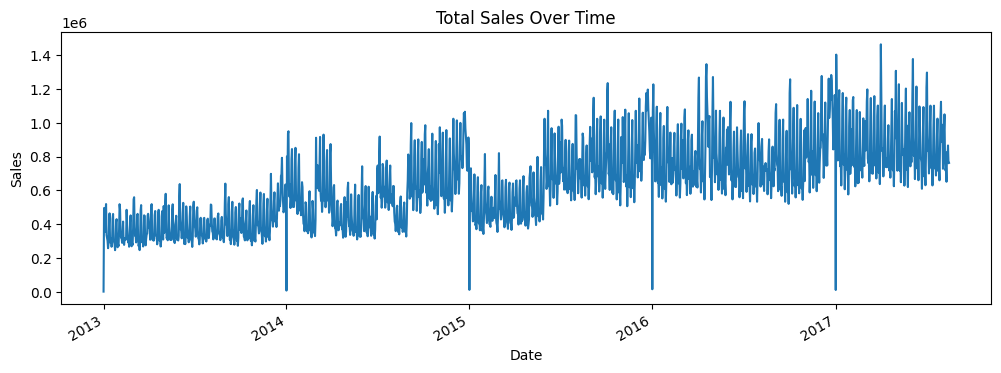

In [6]:
# sales over time
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(12, 4))
daily_sales.plot()
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [7]:
df = train.copy()

df = df[
    [
        "date",
        "store_nbr",
        "family",
        "sales",
        "onpromotion"
    ]
]

In [8]:
df = df[
    [
        "date",
        "store_nbr",
        "family",
        "sales",
        "onpromotion"
    ]
]

In [9]:
df = df.sort_values(
    ["store_nbr", "family", "date"]
)

In [10]:
df["lag_7"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(7)
)

In [11]:
df["rolling_std_7"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(1)
    .rolling(7)
    .std()
)

In [12]:
df["rolling_mean_7"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [13]:
df["rolling_mean_7"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [14]:
features = [
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "onpromotion"
]

In [15]:
df = df.dropna()

In [16]:
X = df[features]

y = df["sales"]

In [17]:
X.head()

,lag_7,rolling_mean_7,rolling_std_7,onpromotion
12474,0.0,2.142857,1.772811,0
14256,2.0,2.428571,1.511858,0
16038,3.0,2.428571,1.511858,0
17820,3.0,2.285714,1.496026,0
19602,5.0,2.285714,1.496026,0


In [18]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [19]:
scores = []

In [20]:
df_small = df.sample(
    100000,
    random_state=42
).sort_values("date")

In [21]:
X = df_small[features]
y = df_small["sales"]

model = XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [22]:
model.feature_importances_

array([0.24392898, 0.7370146 , 0.0116653 , 0.00739113], dtype=float32)

In [23]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
1,rolling_mean_7,0.737015
0,lag_7,0.243929
2,rolling_std_7,0.011665
3,onpromotion,0.007391


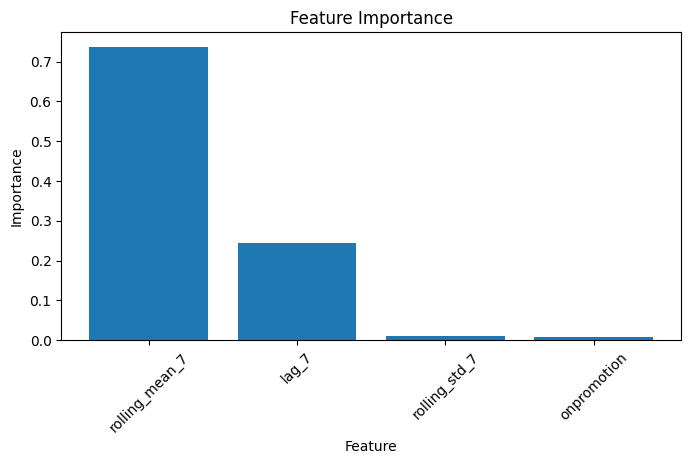

In [24]:
plt.figure(figsize=(8, 4))

plt.bar(
    importance["feature"],
    importance["importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [25]:
print(test.columns)

Index(['id', 'date', 'store_nbr', 'family', 'onpromotion'], dtype='object')


In [26]:
test.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [27]:
df["dayofweek"] = df["date"].dt.dayofweek

In [28]:
df["month"] = df["date"].dt.month

In [29]:
df["day"] = df["date"].dt.day

In [30]:
features = [
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "onpromotion",
    "dayofweek",
    "month",
    "day"
]


In [31]:
X = df[features]
y = df["sales"]

In [32]:
df_small = df.sample(100000, random_state=42).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    pred = model.predict(X.iloc[valid_idx])

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 1.090926570592549


In [33]:
df["lag_14"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(14)
)

In [34]:
df = df.dropna()

In [35]:
features = [
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "onpromotion",
    "dayofweek",
    "month",
    "day"
]


In [36]:
df_small = df.sample(100000, random_state=42).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    pred = model.predict(X.iloc[valid_idx])

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 1.1323970022386425


In [37]:
df["is_weekend"] = (
df["dayofweek"] >= 5
).astype(int)

In [38]:
features = [
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "onpromotion",
    "dayofweek",
    "month",
    "day",
    "is_weekend"
]

In [39]:
X = df[features]
y = df["sales"]

In [40]:
df_small = df.sample(
    100000,
    random_state=42
).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    pred = model.predict(
        X.iloc[valid_idx]
    )

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 1.0882529776423604


In [41]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

          feature  importance
1  rolling_mean_7    0.659712
0           lag_7    0.273297
4       dayofweek    0.025967
6             day    0.012228
5           month    0.011071
2   rolling_std_7    0.009888
3     onpromotion    0.007838
7      is_weekend    0.000000


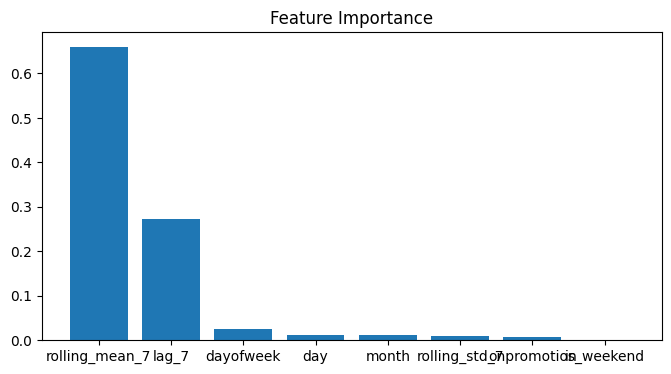

In [42]:
plt.figure(figsize=(8,4))

plt.bar(
    importance["feature"],
    importance["importance"]
)

plt.title("Feature Importance")
plt.show()

In [43]:
features = [
    "rolling_mean_7"
]

In [44]:
features = [
    "rolling_mean_7",
    "lag_7"
]

In [45]:
df_small = df.sample(
    100000,
    random_state=42
).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    pred = model.predict(
        X.iloc[valid_idx]
    )

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 0.9732654150170864


In [46]:
features = [
    "rolling_mean_7"
]

In [47]:
df_small = df.sample(
    100000,
    random_state=42
).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    pred = model.predict(
        X.iloc[valid_idx]
    )

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 0.8260010528622925


In [48]:
df["rolling_mean_14"] = (
    df.groupby(
        ["store_nbr", "family"]
    )["sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

In [49]:
df_small = df.sample(
    100000,
    random_state=42
).sort_values("date")

X = df_small[features]
y = df_small["sales"]

scores = []

for train_idx, valid_idx in TimeSeriesSplit(n_splits=3).split(X):

    model = XGBRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    pred = model.predict(
        X.iloc[valid_idx]
    )

    scores.append(
        np.sqrt(
            mean_squared_log_error(
                y.iloc[valid_idx],
                np.maximum(pred, 0)
            )
        )
    )

print("CV RMSLE:", np.mean(scores))

CV RMSLE: 0.8260010528622925


## Experiment Results

| Features | CV RMSLE |
|---|---:|
| rolling_mean_7 | 0.826 |
| rolling_mean_7 + lag_7 | 0.973 |
| rolling_mean_7 + rolling_mean_14 + trend_7_14 | 0.995 |
| lag_1 + rolling_mean_7 | 0.988 |

## Discussion

The best performance was obtained using only rolling_mean_7.

This suggests that the recent 7-day average sales contains the most useful information for this baseline forecasting task.

Additional lag and trend features did not improve performance in this experiment.

In [50]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

          feature  importance
0  rolling_mean_7         1.0


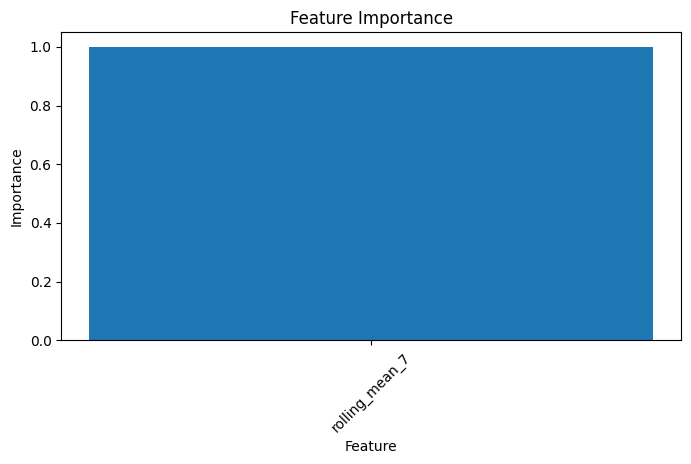

In [51]:
plt.figure(figsize=(8, 4))

plt.bar(
    importance["feature"],
    importance["importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

## Key Findings

- rolling_mean_7 achieved the best validation score.
- Adding additional lag and trend features did not improve performance.
- Cross validation was essential for evaluating feature usefulness.
- More features do not always lead to better performance.

## Conclusion

The rolling_mean_7 feature achieved the best validation score.

This project demonstrates that feature engineering should be evaluated using cross validation, since adding more features does not always improve model performance.